In [7]:
from dotenv import load_dotenv
load_dotenv()

from langchain_unstructured import UnstructuredLoader
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_huggingface import HuggingFaceEmbeddings
import glob
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import TypedDict, List, Literal
import re
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
import glob

In [8]:
#file path
files = glob.glob("documents/**/*", recursive=True)
files

['documents\\Company_Policies.pdf',
 'documents\\Company_Profile.pdf',
 'documents\\Product_and_Pricing.pdf']

In [9]:
loader = UnstructuredLoader(files,chunking_strategy="by_title")    

In [10]:
docs = loader.load()

In [11]:
#splitter
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(docs)


In [12]:
#embedding models
# embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"batch_size": 64, "normalize_embeddings": True}
)

INFO: No device provided, using cpu
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO: Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO: H

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/

In [13]:
#rertriever
retriever = FAISS.from_documents(chunks, embedding_model).as_retriever(search_type='similarity', search_kwargs={'k':4})

INFO: Loading faiss with AVX512 support.
INFO: Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
INFO: Loading faiss with AVX2 support.
INFO: Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
INFO: Loading faiss.
INFO: Successfully loaded faiss.


In [14]:
#model
llm  = ChatGroq(model="openai/gpt-oss-20b")

# 1. retrieval Decision : whether it requires external docs or it can answer in its own

In [15]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    #step 1: creating decision state to check if retrieval is needed
    need_retrieval: bool
    

In [16]:
#for structured output
class retrievalDecision(BaseModel):
    decision : bool

In [17]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Decide whether retrieval is needed to answer the question. "
            "Use the retrievalDecision tool and return only the structured result. "
            "Set decision=True if answering requires specific facts, citations, "
            "or information likely not in the model. Set decision=False for general "
            "explanations, definitions, or reasoning that does not need sources. "
            "If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(
    retrievalDecision)

In [18]:
def decide_retrieval(state: State):
    decision = should_retrieve_llm.invoke(decide_retrieval_prompt.format(question=state["question"]))
    return {"need_retrieval": decision.decision}

In [19]:
# generate direct : which will not retrieve any documents
def generate_direct(state: State):
    answer = llm.invoke(
        [
            (
                "system",
                "You are a helpful assistant. Answer the question based on your knowledge."
            ),
            ("human", f"Question: {state['question']}"),
        ]
    )
    return {"answer": answer.content}


In [20]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}


In [21]:
# function for deciding whether to retrieve or not
def whether_retrieve(state: State):
    if state['need_retrieval']:
        return 'retrieve'
    else :
        return 'generate_direct'

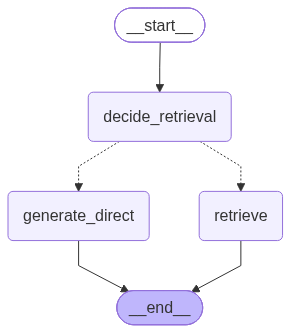

In [22]:
#build graph
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('generate_direct',END)
graph.add_edge('retrieve',END)

#compile
app = graph.compile()
app

In [23]:
result = app.invoke(
    {
        "question": 'who is the CEO of Nexa AI ?'
    }
)

print(result["need_retrieval"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


True


# 2. Creating relevant_docs as key in our State in case our model requires retrieval

In [24]:
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    need_retrieval: bool

    # step 2 : adding relevant_docs
    relevant_docs: List[Document]

In [25]:
# schema for judging docs
class judgeDocs(BaseModel):
    is_relevant : bool = Field(..., description="True if the document is relevant to the question, False otherwise.")

In [26]:
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance. "
            "Return only the provided structured output. "
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

#llm with relevance judgement output
relevance_judgement_llm = llm.with_structured_output(judgeDocs)

In [27]:
#now creating node for judging docs
def is_relevant(state: State):
    question = state["question"]
    docs = state['docs']
    #empty
    relevant_docs : List[Document] = []

    for doc in docs:
        relevant = relevance_judgement_llm.invoke(is_relevant_prompt.format(question=question, document=doc.page_content))
        if relevant.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

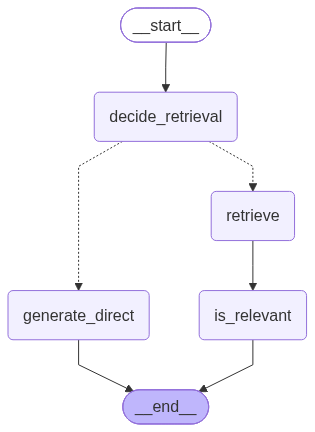

In [28]:
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
graph.add_edge('is_relevant',END)
graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [29]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print(result["need_retrieval"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


True


In [30]:
#check relevant docs
print('\n'.join([i.page_content for i in  result['relevant_docs']]))

Founder

Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and cloud infrastructure.

He previously worked with global consulting firms where he led multiple large-scale digital transformation projects.

Leadership Team

The leadership team brings experience across AI engineering, product management, and business operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product


# 3. Generate from relevant docs

`Generating from relevant documents if available otherwise return "No relevant information found"`

In [31]:
# creating node : generate from context
def generate_from_context(state:State):
    #get question and relevant docs from state
    q = state['question']
    context = '\n'.join([i.page_content for i in state['relevant_docs']])

    #prompt
    prompt = ChatPromptTemplate.from_messages([
        ('system',
         "You are a helpful assistant, answer the following question using only provided context"),
         ('human',
          'Question : {question}\n\n context : {context}')
    ])
    # chain
    generate_from_context_chain  = prompt | llm

    #response
    response = generate_from_context_chain.invoke({'question':q, 'context':context})
    return {'answer': response.content}

In [32]:
# creating node called : no_relevant_docs
def no_relevant_docs(state:State):
    return {'answer':'No relevant information'}

In [33]:
# creating conditional edge function
def docsORnodocs(state:State):
    if state['relevant_docs']:
        return 'generate_from_context'
    else :
        return 'no_relevant_docs'

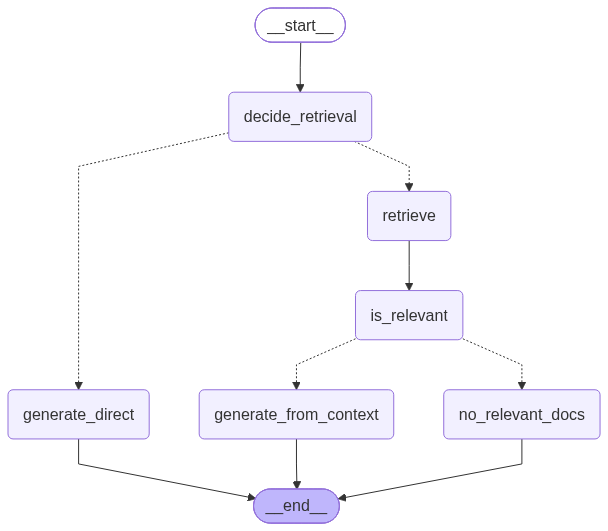

In [34]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
graph.add_edge("generate_from_context", END)
graph.add_edge("no_relevant_docs", END)
#------------------------------------------

graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [35]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print(result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The CEO of NexaAI is **Aarav Mehta**.


In [36]:
result = app.invoke(
    {
        "question": 'who is CEO of apple in 2026?'
    }
)

print(result["answer"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


No relevant information


# 4. Creating "is_sup" node after generating_from_context

`which will check if our generated context is sufficient to answer the question also it will`

In [37]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str
    need_retrieval: bool
    relevant_docs: List[Document]

    #step 4
    is_hallucinating : bool
    is_supporting : str

In [38]:
# creating pydantic schema
class is_suff_schema(BaseModel):
    answer : Literal['fully_supported', 'partially_supported', 'no_supported']
    is_hallucinating : bool = Field(description="Whether the answer is hallucinating or not")
    

In [39]:
is_suff_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'You are a question and answer supervisor. Evaluate how well the generated answer is supported by the provided context.\n\n'
     'Return one of these values for the "answer" field:\n'
     '- fully_supported: when the context contains all information needed to answer the question and the generated answer is accurate based on the context\n'
     '- partially_supported: when the context has some relevant information but is incomplete or the answer has some unsupported details\n'
     '- no_supported: when the context does not contain information to answer the question or the answer contradicts the context\n\n'
     'For is_hallucinating:\n'
     '- True: if the answer contains information not present in the context or makes claims unsupported by the context\n'
     '- False: if the answer is fully derived from the provided context'),
     ('human',
      "Question: {question}\n\nContext: {context}\n\nGenerated Answer: {answer}")
])

#llm with structured output
is_suff_llm = is_suff_prompt | llm.with_structured_output(is_suff_schema)

In [40]:
# def creating is_suff node
def is_suff(state:State):
    question = state['question']
    answer = state['answer']
    context = '\n'.join([i.page_content for i in state['relevant_docs']])

    #output
    res = is_suff_llm.invoke({'question':question,'answer':answer, 'context':context})

    return {'is_supporting': res.answer,
            'is_hallucinating': res.is_hallucinating }

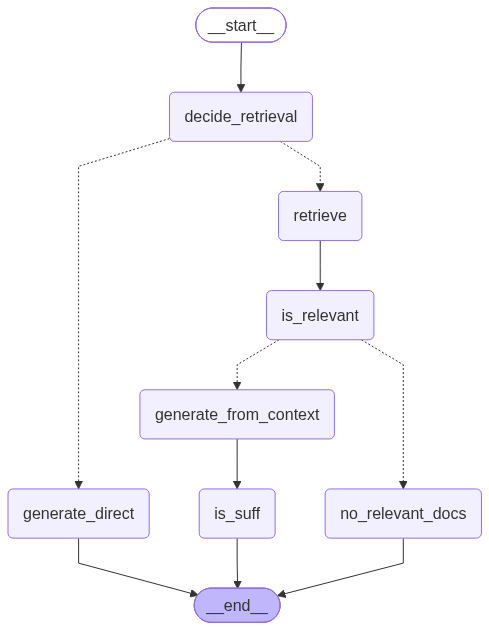

In [41]:
# build graph now
graph  = StateGraph(State)

#adding nodes
graph.add_node('decide_retrieval', decide_retrieval)
graph.add_node('generate_direct', generate_direct)
graph.add_node('retrieve', retrieve)
graph.add_node('is_relevant', is_relevant)
graph.add_node('generate_from_context', generate_from_context)
graph.add_node('no_relevant_docs', no_relevant_docs)
graph.add_node('is_suff',is_suff)

#adding edges
graph.add_edge(START, 'decide_retrieval')
graph.add_conditional_edges('decide_retrieval', whether_retrieve,{'retrieve': 'retrieve', 'generate_direct': 'generate_direct'})

graph.add_edge('retrieve','is_relevant')
#step 3 is adding
graph.add_conditional_edges('is_relevant',docsORnodocs,{'generate_from_context': 'generate_from_context', 'no_relevant_docs': 'no_relevant_docs'})
graph.add_edge("generate_from_context", 'is_suff')
graph.add_edge('is_suff', END)
graph.add_edge("no_relevant_docs", END)
#------------------------------------------

graph.add_edge('generate_direct',END)


#compile
app = graph.compile()
app

In [42]:
result = app.invoke(
    {
        "question": 'who is the CEO of NexaAI ?'
    }
)

print("Answer:", result["answer"])
print("is_supporting:", result["is_supporting"])
print("is_hallucinating:", result["is_hallucinating"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: The CEO of NexaAI is **Aarav Mehta**.
is_supporting: fully_supported
is_hallucinating: False


In [46]:
result = app.invoke(
    {
        "question": 'how  many employes are in NexaAI ?'
    }
)

print("Answer:", result["answer"])
print("is_supporting:", result["is_supporting"])
print("is_hallucinating:", result["is_hallucinating"])

INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
INFO: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answer: NexaAI has **85+ employees**.
is_supporting: fully_supported
is_hallucinating: False
